## Vessel location density by season

2D density map of cala locations pooled across all years, split by primera and segunda temporada.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

OUT   = Path('/home/jupyter-daniela/suyana/peru_production/outputs/')
PLOTS = Path('/home/jupyter-daniela/peru_catch_modeling/outputs')
PLOTS.mkdir(exist_ok=True)

PROJ = ccrs.PlateCarree()

def add_gridlines(ax):
    gl = ax.gridlines(crs=PROJ, draw_labels=True,
                      linewidth=0.4, color='grey', alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}

In [2]:
df_raw = pd.read_csv(OUT / 'calas_all_data.csv', low_memory=False)

rename_map = {
    'fecha_cala': 'date',
    'temporada':  'season',
    'latitud':    'lat',
    'longitud':   'lon',
    'declarado_tm': 'catch_tm',
}
df_raw = df_raw.rename(columns={k: v for k, v in rename_map.items() if k in df_raw.columns})
df_raw['date'] = pd.to_datetime(df_raw['date'], errors='coerce')

# extract season type: handles '1ra XXXX', '2da XXXX', 'XXXX_CN-I', 'XXXX_CN-II'
def get_season_type(s):
    if pd.isna(s):
        return np.nan
    s = str(s)
    if s.startswith('1ra') or s.endswith('CN-I'):
        return '1ra'
    if s.startswith('2da') or s.endswith('CN-II'):
        return '2da'
    return np.nan

df_raw['season_type'] = df_raw['season'].apply(get_season_type)

print(f"Total calas: {len(df_raw):,}")
print(f"Years: {sorted(df_raw['date'].dt.year.dropna().unique().tolist())}")
print(df_raw['season_type'].value_counts())
print(df_raw[['lat', 'lon', 'season', 'season_type']].head())

Total calas: 357,684
Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
season_type
2da    183064
1ra    174620
Name: count, dtype: int64
        lat        lon    season season_type
0 -9.516667 -78.683333  2da 2015         2da
1 -9.483333 -78.683333  2da 2015         2da
2 -9.516667 -78.683333  2da 2015         2da
3 -9.566667 -78.650000  2da 2015         2da
4 -9.533333 -78.650000  2da 2015         2da


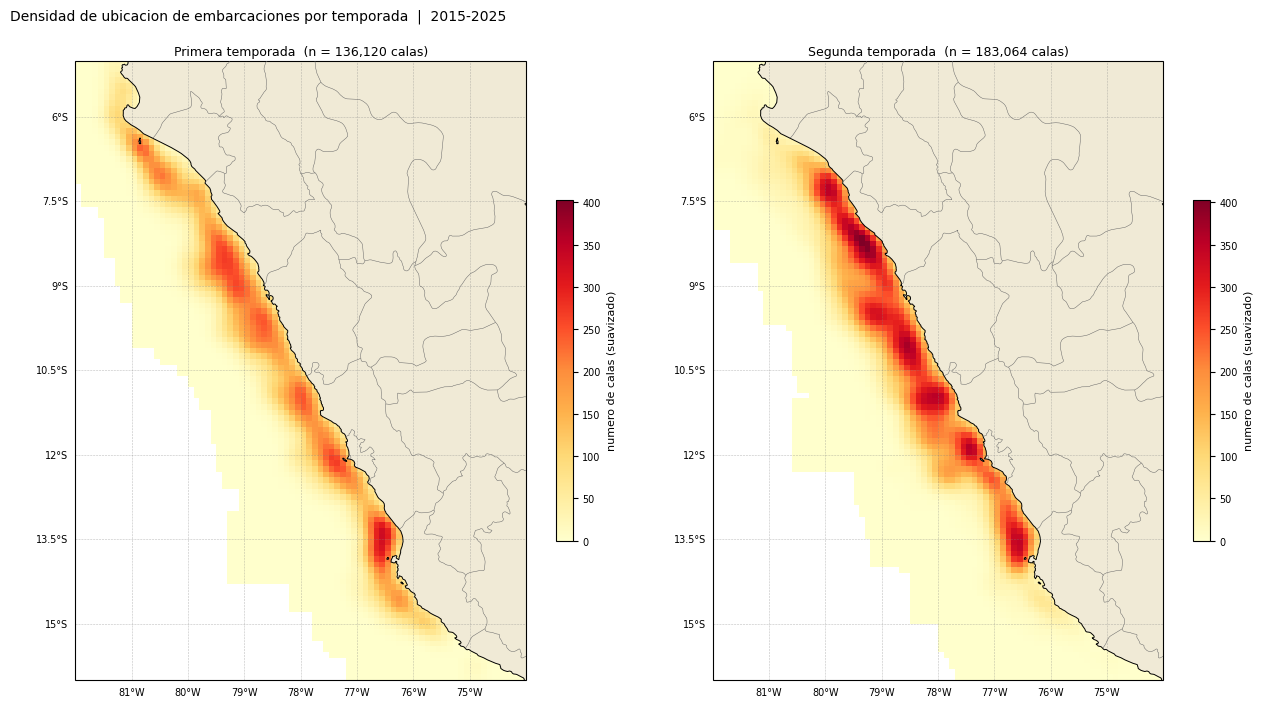

Guardado -> /home/jupyter-daniela/peru_catch_modeling/outputs/step8a_vessel_density_by_season.png


In [3]:
from scipy.ndimage import gaussian_filter
import cartopy.io.shapereader as shpreader

# zoomed extent as requested
LON_MIN, LON_MAX = -82, -74
LAT_MIN, LAT_MAX = -16, -5

# ~0.1 deg bins
LON_EDGES = np.linspace(LON_MIN, LON_MAX, 81)
LAT_EDGES = np.linspace(LAT_MIN, LAT_MAX, 111)
LON_C = (LON_EDGES[:-1] + LON_EDGES[1:]) / 2
LAT_C = (LAT_EDGES[:-1] + LAT_EDGES[1:]) / 2

EXT_ZOOM = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]

# divisiones administrativas (departamentos)
states_10m = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none',
)

fig, axes = plt.subplots(1, 2, figsize=(13, 7),
                         subplot_kw={'projection': PROJ})

labels = {'1ra': 'Primera temporada', '2da': 'Segunda temporada'}

grids = {}
for stype in ['1ra', '2da']:
    sub = df_raw[df_raw['season_type'] == stype].dropna(subset=['lat', 'lon'])
    H, _, _ = np.histogram2d(sub['lon'], sub['lat'],
                             bins=[LON_EDGES, LAT_EDGES])
    H_smooth = gaussian_filter(H.T.astype(float), sigma=1.5)
    grids[stype] = H_smooth

vmax = max(g.max() for g in grids.values())

for ax, stype in zip(axes, ['1ra', '2da']):
    H_masked = np.ma.masked_where(grids[stype] == 0, grids[stype])

    ax.set_extent(EXT_ZOOM, crs=PROJ)
    ax.add_feature(cfeature.LAND,      facecolor='#f0ead6', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7,       zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.6, linestyle='-', zorder=4)
    ax.add_feature(states_10m,         linewidth=0.35, edgecolor='#666666', zorder=4)
    add_gridlines(ax)

    mesh = ax.pcolormesh(LON_C, LAT_C, H_masked,
                         transform=PROJ, cmap='YlOrRd',
                         vmin=0, vmax=vmax, zorder=1)

    cb = plt.colorbar(mesh, ax=ax, shrink=0.55, pad=0.05)
    cb.set_label('numero de calas (suavizado)', size=8)
    cb.ax.tick_params(labelsize=7)

    n_total = int(df_raw[df_raw['season_type'] == stype].dropna(subset=['lat', 'lon']).shape[0])
    ax.set_title(f"{labels[stype]}  (n = {n_total:,} calas)", fontsize=9, pad=4)

fig.suptitle('Densidad de ubicacion de embarcaciones por temporada  |  2015-2025',
             fontsize=10, x=0.01, ha='left', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(PLOTS / 'step8a_vessel_density_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado -> {PLOTS / 'step8a_vessel_density_by_season.png'}")